In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    X = batch[b"data"]
    y = batch[b"labels"]

    return X, np.array(y)

In [4]:
X1, y1 = load_batch("/content/data_batch_1")
X2, y2 = load_batch("/content/data_batch_2")
X3, y3 = load_batch("/content/data_batch_3")
X4, y4 = load_batch("/content/data_batch_4")
X5, y5 = load_batch("/content/data_batch_5")

In [5]:
X_train = np.concatenate([X1, X2, X3, X4, X5], axis=0)
y_train = np.concatenate([y1, y2, y3, y4, y5], axis=0)

In [6]:
X_test, y_test = load_batch(
    "/content/test_batch"
)

In [7]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(50000, 3072)
(50000,)
(10000, 3072)
(10000,)


<h3>Normalisation

In [8]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

<h3>Class Naming

In [9]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [10]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

<h3>Choosing smaller no of traing and testing images by stratified sampling </h3>

In [11]:
np.random.seed(42)

def stratified_sample(X, y, samples_per_class):

    selected_indices = []

    for class_label in range(10):

        # Find all indices belonging to this class
        class_indices = np.where(y == class_label)[0]

        # Randomly select required number
        selected = np.random.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(selected)

    # Shuffle selected indices
    selected_indices = np.array(selected_indices)

    np.random.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


# 100 images from each class
X_train_small, y_train_small = stratified_sample(
    X_train,
    y_train,
    100
)

# 20 images from each class
X_test_small, y_test_small = stratified_sample(
    X_test,
    y_test,
    20
)


print("Training shape:", X_train_small.shape)
print("Testing shape :", X_test_small.shape)

Training shape: (1000, 3072)
Testing shape : (200, 3072)


<h3>Distance Functions

In [12]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))


def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


def cosine_distance(x1, x2):
    numerator = np.dot(x1, x2)

    denominator = np.sqrt(np.sum(x1 ** 2)) * np.sqrt(np.sum(x2 ** 2))

    if denominator == 0:
        return 1
    similarity = numerator / denominator

    return 1 - similarity


def hamming_distance(x1, x2):
    return np.sum(x1 != x2)

<h3>KNN function

In [13]:
def knn_predict(X_train, y_train, X_test, k, distance_metric):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            if distance_metric == "euclidean":

                distance = euclidean_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "manhattan":

                distance = manhattan_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "minkowski":

                distance = minkowski_distance(
                    test_point,
                    X_train[i],
                    p=3
                )

            elif distance_metric == "cosine":

                distance = cosine_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "hamming":

                distance = hamming_distance(
                    test_point,
                    X_train[i]
                )

            distances.append(
                (distance, y_train[i])
            )

        # Sort according to distance
        distances.sort(
            key=lambda x: x[0]
        )

        # Select K nearest neighbours
        nearest_neighbors = distances[:k]

        # Get their labels
        neighbor_labels = [
            label
            for distance, label in nearest_neighbors
        ]

        # Majority voting
        prediction = np.bincount(
            neighbor_labels,
            minlength=10
        ).argmax()

        predictions.append(prediction)

    return np.array(predictions)

<h2>Performance Measures
<h3>Accuracy

In [14]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

<h3>Confusion Matrix

In [15]:
def confusion_matrix(y_true, y_pred):

    cm = np.zeros(
        (10, 10),
        dtype=int
    )

    for actual, predicted in zip(
        y_true,
        y_pred
    ):

        cm[actual][predicted] += 1

    return cm

<h3>Precision and Recall

In [16]:
def precision_recall(y_true, y_pred):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    precision = []
    recall = []

    for i in range(10):

        TP = cm[i][i]

        FP = np.sum(cm[:, i]) - TP

        FN = np.sum(cm[i, :]) - TP

        if TP + FP == 0:
            p = 0
        else:
            p = TP / (TP + FP)

        if TP + FN == 0:
            r = 0
        else:
            r = TP / (TP + FN)

        precision.append(p)
        recall.append(r)

    return np.array(precision), np.array(recall)

<h3>Testing on one value of k and one metic

In [17]:
k = 3
metric = "euclidean"

In [18]:
y_pred = knn_predict(
    X_train_small,
    y_train_small,
    X_test_small,
    k,
    metric
)

In [19]:
accuracy = accuracy_score(
    y_test_small,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.28


In [20]:
cm = confusion_matrix(
    y_test_small,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  0  2  0  2  0  0  0  4  0]
 [ 5  5  2  1  4  0  0  1  2  0]
 [ 1  0 12  0  2  0  2  0  3  0]
 [ 4  1  6  2  4  1  2  0  0  0]
 [ 2  0  8  1  5  0  3  1  0  0]
 [ 3  0  9  1  5  0  0  0  2  0]
 [ 2  0  8  0  4  0  6  0  0  0]
 [ 7  0  4  0  3  0  3  2  1  0]
 [ 4  1  0  0  2  0  0  0 12  1]
 [ 9  1  3  1  1  0  2  0  3  0]]


In [21]:
precision, recall = precision_recall(
    y_test_small,
    y_pred
)

In [22]:
for i in range(10):

    print(
        class_names[i],
        "Precision:",
        round(precision[i], 4),
        "Recall:",
        round(recall[i], 4)
    )

airplane Precision: 0.2449 Recall: 0.6
automobile Precision: 0.625 Recall: 0.25
bird Precision: 0.2222 Recall: 0.6
cat Precision: 0.3333 Recall: 0.1
deer Precision: 0.1562 Recall: 0.25
dog Precision: 0.0 Recall: 0.0
frog Precision: 0.3333 Recall: 0.3
horse Precision: 0.5 Recall: 0.1
ship Precision: 0.4444 Recall: 0.6
truck Precision: 0.0 Recall: 0.0


<h3>Experiment with all values of K and distance metrics

In [23]:
k_values = [3, 4, 9, 20, 47]

distance_metrics = [
    "euclidean",
    "manhattan",
    "minkowski",
    "cosine",
    "hamming"
]

In [24]:
results = []

best_accuracy = 0
best_k = None
best_metric = None
best_predictions = None

In [25]:
k_values = [3, 4, 9, 20, 47]

distance_metrics = [
    "euclidean",
    "manhattan",
    "minkowski",
    "cosine",
    "hamming"
]

In [26]:
for metric in distance_metrics:

    print("\nDistance:", metric)

    for k in k_values:

        y_pred = knn_predict(
            X_train_small,
            y_train_small,
            X_test_small,
            k,
            metric
        )

        accuracy = accuracy_score(
            y_test_small,
            y_pred
        )

        results.append({
            "Distance": metric,
            "K": k,
            "Accuracy": accuracy
        })

        print(
            "K =", k,
            "Accuracy =",
            round(accuracy, 4)
        )

        if accuracy > best_accuracy:

            best_accuracy = accuracy
            best_k = k
            best_metric = metric
            best_predictions = y_pred


Distance: euclidean
K = 3 Accuracy = 0.28
K = 4 Accuracy = 0.26
K = 9 Accuracy = 0.235
K = 20 Accuracy = 0.26
K = 47 Accuracy = 0.255

Distance: manhattan
K = 3 Accuracy = 0.28
K = 4 Accuracy = 0.3
K = 9 Accuracy = 0.265
K = 20 Accuracy = 0.265
K = 47 Accuracy = 0.265

Distance: minkowski
K = 3 Accuracy = 0.205
K = 4 Accuracy = 0.21
K = 9 Accuracy = 0.215
K = 20 Accuracy = 0.21
K = 47 Accuracy = 0.205

Distance: cosine
K = 3 Accuracy = 0.27
K = 4 Accuracy = 0.24
K = 9 Accuracy = 0.26
K = 20 Accuracy = 0.26
K = 47 Accuracy = 0.25

Distance: hamming
K = 3 Accuracy = 0.245
K = 4 Accuracy = 0.25
K = 9 Accuracy = 0.28
K = 20 Accuracy = 0.265
K = 47 Accuracy = 0.26


In [27]:
results_df = pd.DataFrame(results)

print("\n========== RESULTS ==========")

print(results_df)


========== RESULTS ==========
     Distance   K  Accuracy
0   euclidean   3     0.280
1   euclidean   4     0.260
2   euclidean   9     0.235
3   euclidean  20     0.260
4   euclidean  47     0.255
5   manhattan   3     0.280
6   manhattan   4     0.300
7   manhattan   9     0.265
8   manhattan  20     0.265
9   manhattan  47     0.265
10  minkowski   3     0.205
11  minkowski   4     0.210
12  minkowski   9     0.215
13  minkowski  20     0.210
14  minkowski  47     0.205
15     cosine   3     0.270
16     cosine   4     0.240
17     cosine   9     0.260
18     cosine  20     0.260
19     cosine  47     0.250
20    hamming   3     0.245
21    hamming   4     0.250
22    hamming   9     0.280
23    hamming  20     0.265
24    hamming  47     0.260


In [28]:
print("\n========== BEST MODEL ==========")

print("Best K:", best_k)

print("Best Distance:", best_metric)

print(
    "Best Accuracy:",
    round(best_accuracy, 4)
)


========== BEST MODEL ==========
Best K: 4
Best Distance: manhattan
Best Accuracy: 0.3


In [29]:
cm = confusion_matrix(
    y_test_small,
    best_predictions
)

print("\n========== CONFUSION MATRIX ==========")

print(cm)


========== CONFUSION MATRIX ==========
[[11  0  4  0  1  0  0  0  4  0]
 [ 3  6  2  0  7  0  0  0  2  0]
 [ 2  0 12  0  3  0  1  0  2  0]
 [ 5  0  5  2  2  1  3  0  2  0]
 [ 0  1  6  1  7  0  3  2  0  0]
 [ 2  0  8  1  6  0  1  1  1  0]
 [ 3  0  7  0  4  1  5  0  0  0]
 [ 4  1  4  0  4  1  3  2  1  0]
 [ 3  0  0  0  3  0  1  0 12  1]
 [ 4  3  2  0  1  0  1  1  5  3]]


In [30]:
precision, recall = precision_recall(
    y_test_small,
    best_predictions
)

In [31]:
print("\n========== PRECISION & RECALL ==========")

for i in range(10):

    print(
        class_names[i],
        "-> Precision:",
        round(precision[i], 4),
        "Recall:",
        round(recall[i], 4)
    )


========== PRECISION & RECALL ==========
airplane -> Precision: 0.2973 Recall: 0.55
automobile -> Precision: 0.5455 Recall: 0.3
bird -> Precision: 0.24 Recall: 0.6
cat -> Precision: 0.5 Recall: 0.1
deer -> Precision: 0.1842 Recall: 0.35
dog -> Precision: 0.0 Recall: 0.0
frog -> Precision: 0.2778 Recall: 0.25
horse -> Precision: 0.3333 Recall: 0.1
ship -> Precision: 0.4138 Recall: 0.6
truck -> Precision: 0.75 Recall: 0.15


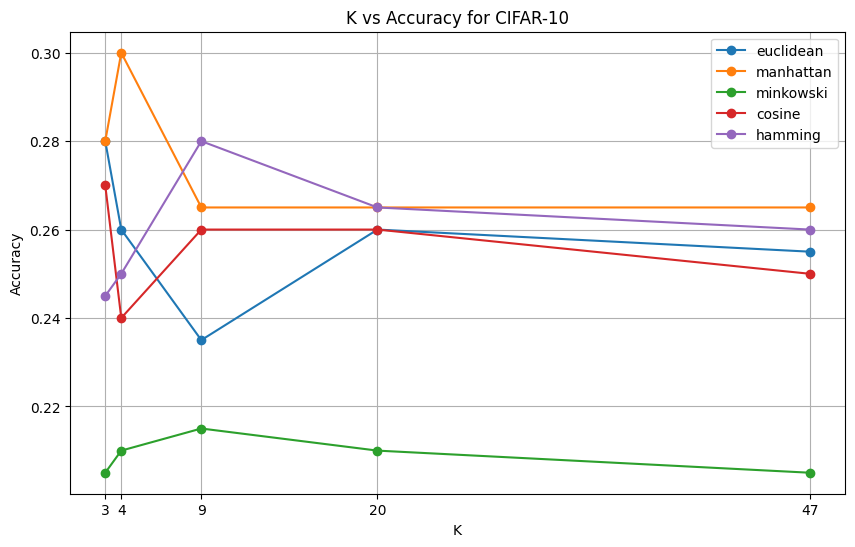

In [32]:
plt.figure(figsize=(10, 6))

for metric in distance_metrics:

    metric_results = results_df[
        results_df["Distance"] == metric
    ]

    plt.plot(
        metric_results["K"],
        metric_results["Accuracy"],
        marker="o",
        label=metric
    )

plt.xlabel("K")
plt.ylabel("Accuracy")

plt.title(
    "K vs Accuracy for CIFAR-10"
)

plt.xticks(k_values)

plt.legend()

plt.grid(True)

plt.show()

<h3>Saving current result

In [33]:
results_1000_200 = results_df.copy()

# Also save the best model information
best_1000_200 = {
    "Best K": best_k,
    "Best Distance": best_metric,
    "Best Accuracy": best_accuracy
}

print("1000/200 results saved!")
print(best_1000_200)

1000/200 results saved!
{'Best K': 4, 'Best Distance': 'manhattan', 'Best Accuracy': np.float64(0.3)}


In [34]:
results_1000_200.to_csv(
    "knn_results_1000_200.csv",
    index=False
)

<h2>Increasing No of samples to see effect to train and test size on accuracy

<h3>Increasing no of train samples from 100 per class to 200 per class and test samples from 20 per class to 40 per class

In [35]:
X_train_2000, y_train_2000 = stratified_sample(
    X_train,
    y_train,
    200
)

X_test_400, y_test_400 = stratified_sample(
    X_test,
    y_test,
    40
)

In [36]:
results_2000_400 = []

best_accuracy_2000 = 0
best_k_2000 = None
best_metric_2000 = None
best_predictions_2000 = None

In [37]:
for metric in distance_metrics:

    print("\nDistance:", metric)

    for k in k_values:

        y_pred = knn_predict(
            X_train_2000,
            y_train_2000,
            X_test_400,
            k,
            metric
        )

        accuracy = accuracy_score(
            y_test_400,
            y_pred
        )

        results_2000_400.append({
            "Distance": metric,
            "K": k,
            "Accuracy": accuracy
        })

        print(
            "K =", k,
            "Accuracy =", round(accuracy, 4)
        )

        if accuracy > best_accuracy_2000:

            best_accuracy_2000 = accuracy
            best_k_2000 = k
            best_metric_2000 = metric
            best_predictions_2000 = y_pred


Distance: euclidean
K = 3 Accuracy = 0.26
K = 4 Accuracy = 0.265
K = 9 Accuracy = 0.2675
K = 20 Accuracy = 0.2575
K = 47 Accuracy = 0.2975

Distance: manhattan
K = 3 Accuracy = 0.2525
K = 4 Accuracy = 0.28
K = 9 Accuracy = 0.2725
K = 20 Accuracy = 0.2875
K = 47 Accuracy = 0.2725

Distance: minkowski
K = 3 Accuracy = 0.2275
K = 4 Accuracy = 0.2425
K = 9 Accuracy = 0.245
K = 20 Accuracy = 0.26
K = 47 Accuracy = 0.2475

Distance: cosine
K = 3 Accuracy = 0.2425
K = 4 Accuracy = 0.2475
K = 9 Accuracy = 0.27
K = 20 Accuracy = 0.2875
K = 47 Accuracy = 0.275

Distance: hamming
K = 3 Accuracy = 0.1875
K = 4 Accuracy = 0.18
K = 9 Accuracy = 0.2025
K = 20 Accuracy = 0.245
K = 47 Accuracy = 0.2725


In [38]:
results_2000_400 = pd.DataFrame(
    results_2000_400
)

In [39]:
print("===== 1000/200 =====")

print(
    "Best K:",
    best_1000_200["Best K"]
)

print(
    "Best Metric:",
    best_1000_200["Best Distance"]
)

print(
    "Best Accuracy:",
    best_1000_200["Best Accuracy"]
)


print("\n===== 2000/400 =====")

print(
    "Best K:",
    best_k_2000
)

print(
    "Best Metric:",
    best_metric_2000
)

print(
    "Best Accuracy:",
    best_accuracy_2000
)

===== 1000/200 =====
Best K: 4
Best Metric: manhattan
Best Accuracy: 0.3

===== 2000/400 =====
Best K: 47
Best Metric: euclidean
Best Accuracy: 0.2975


In [40]:
results_1000_200.to_csv(
    "results_1000_200.csv",
    index=False
)

results_2000_400.to_csv(
    "results_2000_400.csv",
    index=False
)